# GRAZPEDWRI-DX: Severity Label + Feature Extraction

**Зорилго:**
1. Figshare-с датасет татах
2. Файлын нэрнээс нас, хүйс задлах
3. YOLO annotation-аас severity proxy label үүсгэх
4. EfficientNet-B3 shared encoder-ээр feature extraction
5. Google Drive-д хадгалах

In [ ]:
!pip install -q timm

In [ ]:
import os
import re
import json
import glob
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Google Drive холбох

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/GRAZPEDWRI_Features'
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


## 2. Датасет татах (Figshare API)

In [ ]:
import requests

DATA_ROOT = '/content/GRAZPEDWRI-DX'
os.makedirs(DATA_ROOT, exist_ok=True)

article_id = '14825193'
api_url = f'https://api.figshare.com/v2/articles/{article_id}'
response = requests.get(api_url).json()

print(f'Нийт файл: {len(response["files"])}')
print(f'Нийт хэмжээ: {sum(f["size"] for f in response["files"])/(1024**3):.2f} GB')
print()

for f in response['files']:
    filepath = os.path.join(DATA_ROOT, f['name'])
    if os.path.exists(filepath):
        print(f'  [SKIP] {f["name"]} аль хэдийн байна')
        continue
    size_mb = f['size'] / (1024**2)
    print(f'  Татаж байна: {f["name"]} ({size_mb:.1f} MB)')
    !wget -q -O "{filepath}" "{f['download_url']}"
    print(f'  Дууслаа: {f["name"]}')

Нийт файл: 6
Нийт хэмжээ: 15.14 GB

  Татаж байна: dataset.csv (1.8 MB)
  Дууслаа: dataset.csv
  Татаж байна: folder_structure.zip (25.1 MB)
  Дууслаа: folder_structure.zip
  Татаж байна: images_part1.zip (3859.0 MB)
  Дууслаа: images_part1.zip
  Татаж байна: images_part2.zip (3931.3 MB)
  Дууслаа: images_part2.zip
  Татаж байна: images_part3.zip (3672.6 MB)
  Дууслаа: images_part3.zip
  Татаж байна: images_part4.zip (4012.7 MB)
  Дууслаа: images_part4.zip


In [ ]:
# ZIP задлах
for zf in sorted(glob.glob(os.path.join(DATA_ROOT, '*.zip'))):
    print(f'Задалж байна: {os.path.basename(zf)}')
    with zipfile.ZipFile(zf, 'r') as z:
        z.extractall(DATA_ROOT)
    print(f'  Дууслаа')

# Бүтцийг харах
!find {DATA_ROOT} -maxdepth 3 -type d | head -30

Задалж байна: folder_structure.zip
  Дууслаа
Задалж байна: images_part1.zip
  Дууслаа
Задалж байна: images_part2.zip
  Дууслаа
Задалж байна: images_part3.zip
  Дууслаа
Задалж байна: images_part4.zip
  Дууслаа
/content/GRAZPEDWRI-DX
/content/GRAZPEDWRI-DX/notebooks
/content/GRAZPEDWRI-DX/pascalvoc
/content/GRAZPEDWRI-DX/supervisely
/content/GRAZPEDWRI-DX/supervisely/wrist
/content/GRAZPEDWRI-DX/supervisely/wrist/ann
/content/GRAZPEDWRI-DX/supervisely/wrist/img
/content/GRAZPEDWRI-DX/yolov5
/content/GRAZPEDWRI-DX/yolov5/images
/content/GRAZPEDWRI-DX/yolov5/labels


## 3. Файлын нэрнээс нас, хүйс задлах

Файлын нэрний бүтэц:
```
XXXX_XXXXXXXXXX_XX_WRI-XX_[M/F]XXX.png
  |                            |  |
  patient_id                 sex  age
```
Жишээ: `0038_0775938745_03_WRI-L2_M014.png` -> Male, 14 нас

In [ ]:
def parse_filename(filename):
    """Файлын нэрнээс хүйс, нас задлах"""
    basename = Path(filename).stem
    match = re.search(r'_([MFU])(\d{3})$', basename)
    if match:
        sex_code = match.group(1)
        age = int(match.group(2))
        sex = {'M': 'Male', 'F': 'Female', 'U': 'Unknown'}.get(sex_code, 'Unknown')
        return sex, age
    return 'Unknown', -1

def parse_patient_id(filename):
    """Өвчтөний дугаар задлах"""
    basename = Path(filename).stem
    match = re.match(r'^(\d{4})_', basename)
    if match:
        return match.group(1)
    return None

# PNG зургуудыг олох
all_images = glob.glob(os.path.join(DATA_ROOT, '**', '*.png'), recursive=True)
# Annotation/label файлуудыг хасах
all_images = [p for p in all_images if 'labels' not in p and 'annotations' not in p.lower()]
all_images = list(set(all_images))
print(f'Нийт олдсон зураг: {len(all_images)}')

# Metadata задлах
metadata_list = []
for img_path in tqdm(all_images, desc='Metadata задалж байна'):
    fname = os.path.basename(img_path)
    sex, age = parse_filename(fname)
    patient_id = parse_patient_id(fname)
    metadata_list.append({
        'image_path': img_path,
        'filename': fname,
        'patient_id': patient_id,
        'sex': sex,
        'age': age,
    })

df_meta = pd.DataFrame(metadata_list)
print(f'Нийт бичлэг: {len(df_meta)}')
print(f'\nХүйсийн тархалт:')
print(df_meta['sex'].value_counts())
print(f'\nНасны статистик:')
valid_ages = df_meta[df_meta['age'] >= 0]['age']
print(f'  Дундаж: {valid_ages.mean():.1f}, Медиан: {valid_ages.median():.0f}')
print(f'  Мин: {valid_ages.min()}, Макс: {valid_ages.max()}')

Нийт олдсон зураг: 20327


Metadata задалж байна:   0%|          | 0/20327 [00:00<?, ?it/s]

Нийт бичлэг: 20327

Хүйсийн тархалт:
sex
Male       12040
Female      8285
Unknown        2
Name: count, dtype: int64

Насны статистик:
  Дундаж: 10.5, Медиан: 11
  Мин: 0, Макс: 19


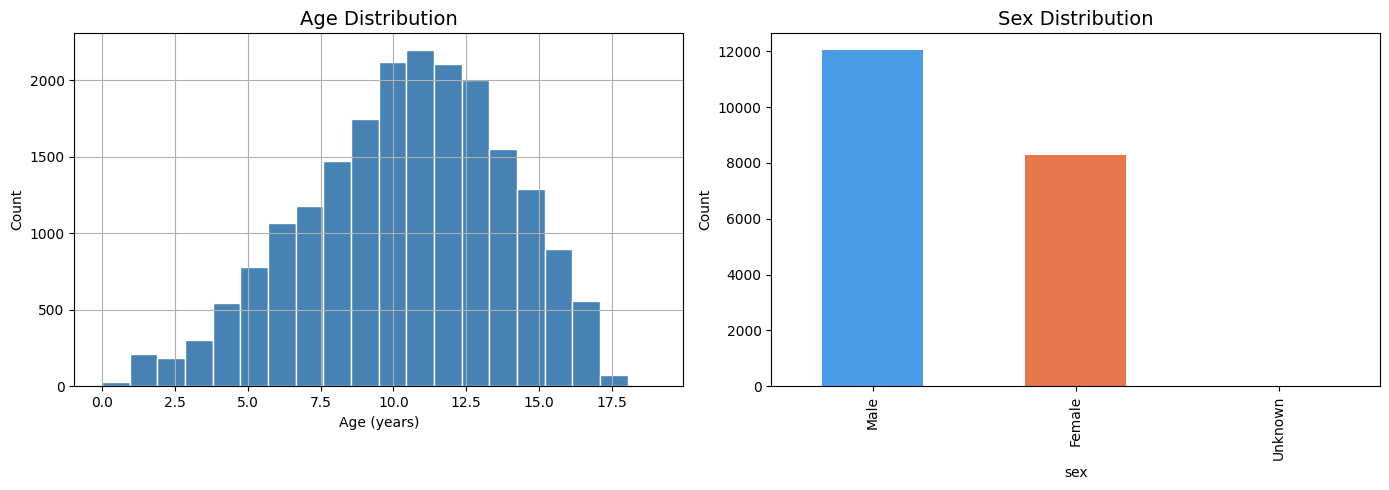

In [ ]:
# Насны болон хүйсийн тархалтын график
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

valid_ages.hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution', fontsize=14)
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')

df_meta['sex'].value_counts().plot.bar(ax=axes[1], color=['#4C9BE8', '#E8774C', '#999'])
axes[1].set_title('Sex Distribution', fontsize=14)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'demographics.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. YOLO Annotation-аас Severity Proxy Label үүсгэх

GRAZPEDWRI-DX классууд:
- 0: boneanomaly
- 1: bonelesion
- 2: foreignbody
- 3: fracture
- 4: metal
- 5: periostealreaction
- 6: pronatorsign
- 7: softtissue
- 8: text

**Severity тодорхойлолт:**
- Grade 0: Хугарал байхгүй (fracture tag байхгүй)
- Grade 1: Энгийн (1 fracture bbox, area < 0.02)
- Grade 2: Дунд зэрэг (1 том bbox эсвэл 2 bbox)
- Grade 3: Хүнд (3+ bbox эсвэл нэмэлт pathology)

In [ ]:
def load_yolo_labels(label_dir):
    """YOLO label файлуудаас fracture bbox мэдээлэл уншиж severity үүсгэнэ"""
    severity_map = {}
    label_files = glob.glob(os.path.join(label_dir, '**', '*.txt'), recursive=True)
    print(f'YOLO label файлын тоо: {len(label_files)}')

    FRACTURE_CLASS = 3
    SEVERE_CLASSES = {0, 1, 5}  # boneanomaly, bonelesion, periostealreaction

    for lf in label_files:
        fname = Path(lf).stem
        fracture_bboxes = []
        has_severe_pathology = False

        with open(lf, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls_id = int(parts[0])
                if cls_id == FRACTURE_CLASS:
                    w, h = float(parts[3]), float(parts[4])
                    bbox_area = w * h
                    fracture_bboxes.append(bbox_area)
                if cls_id in SEVERE_CLASSES:
                    has_severe_pathology = True

        n_fractures = len(fracture_bboxes)
        total_area = sum(fracture_bboxes)

        if n_fractures == 0:
            severity = 0
        elif n_fractures == 1 and total_area < 0.02:
            severity = 1
        elif n_fractures <= 2 or (n_fractures == 1 and total_area >= 0.02):
            severity = 2
        else:
            severity = 3

        if has_severe_pathology and severity > 0:
            severity = min(severity + 1, 3)

        severity_map[fname] = {
            'severity': severity,
            'n_fractures': n_fractures,
            'total_fracture_area': total_area,
            'has_severe_pathology': has_severe_pathology,
        }

    return severity_map

# YOLO label хавтас олох
yolo_label_dirs = glob.glob(os.path.join(DATA_ROOT, '**', 'yolov5', 'labels'), recursive=True)
if not yolo_label_dirs:
    yolo_label_dirs = glob.glob(os.path.join(DATA_ROOT, '**', 'labels'), recursive=True)

print(f'Олдсон label хавтас: {yolo_label_dirs}')

severity_map = {}
for ld in yolo_label_dirs:
    smap = load_yolo_labels(ld)
    severity_map.update(smap)
    print(f'  {ld}: {len(smap)} label')

print(f'\nНийт severity label: {len(severity_map)}')

Олдсон label хавтас: ['/content/GRAZPEDWRI-DX/yolov5/labels']
YOLO label файлын тоо: 20327
  /content/GRAZPEDWRI-DX/yolov5/labels: 20327 label

Нийт severity label: 20327


In [ ]:
# CSV tag файл шалгах
csv_files = glob.glob(os.path.join(DATA_ROOT, '**', '*.csv'), recursive=True)
print(f'Олдсон CSV файлууд: {csv_files}')
for cf in csv_files:
    df_csv = pd.read_csv(cf)
    print(f'\n{cf}')
    print(f'  Баганууд: {list(df_csv.columns)}')
    print(f'  Мөрийн тоо: {len(df_csv)}')
    print(df_csv.head(3))

Олдсон CSV файлууд: ['/content/GRAZPEDWRI-DX/dataset.csv']

/content/GRAZPEDWRI-DX/dataset.csv
  Баганууд: ['filestem', 'patient_id', 'study_number', 'timehash', 'gender', 'age', 'laterality', 'projection', 'initial_exam', 'ao_classification', 'cast', 'diagnosis_uncertain', 'osteopenia', 'fracture_visible', 'metal', 'pixel_spacing', 'device_manufacturer']
  Мөрийн тоо: 20327
                         filestem  patient_id  study_number    timehash  \
0  0001_1297860395_01_WRI-L1_M014           1             1  1297860395   
1  0001_1297860435_01_WRI-L2_M014           1             1  1297860435   
2  0002_0354485735_01_WRI-R1_F012           2             1   354485735   

  gender   age laterality  projection  initial_exam ao_classification  cast  \
0      M  14.1          L           1           1.0         23r-M/2.1   NaN   
1      M  14.1          L           2           1.0         23r-M/2.1   NaN   
2      F  12.0          R           1           1.0         23r-M/2.1   NaN   

   d

In [ ]:
# Severity label-г metadata-д нэмэх
df_meta['stem'] = df_meta['filename'].apply(lambda x: Path(x).stem)
df_meta['severity'] = df_meta['stem'].map(
    lambda s: severity_map.get(s, {}).get('severity', -1)
)
df_meta['n_fractures'] = df_meta['stem'].map(
    lambda s: severity_map.get(s, {}).get('n_fractures', 0)
)
df_meta['total_fracture_area'] = df_meta['stem'].map(
    lambda s: severity_map.get(s, {}).get('total_fracture_area', 0.0)
)
df_meta['has_severe_pathology'] = df_meta['stem'].map(
    lambda s: severity_map.get(s, {}).get('has_severe_pathology', False)
)

print('Severity тархалт:')
sev_counts = df_meta[df_meta['severity'] >= 0]['severity'].value_counts().sort_index()
print(sev_counts)
print(f'\nSeverity label байхгүй: {(df_meta["severity"] == -1).sum()}')

Severity тархалт:
severity
0    6777
1    4373
2    7190
3    1987
Name: count, dtype: int64

Severity label байхгүй: 0


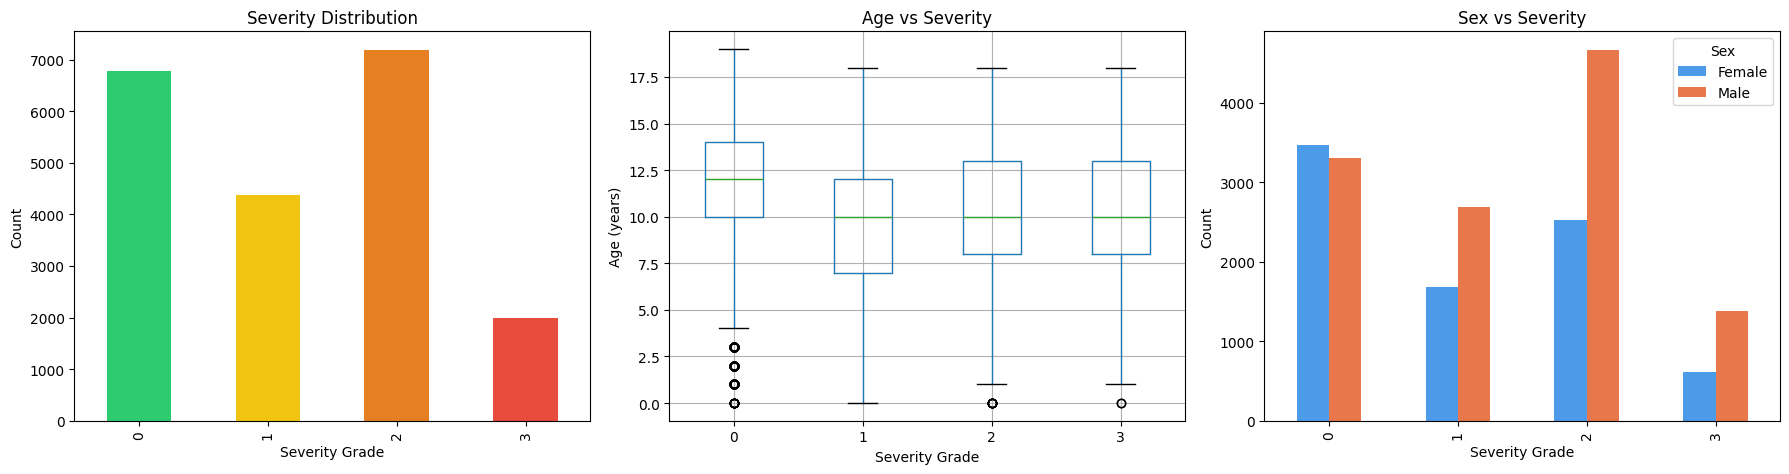

In [ ]:
# Severity тархалтын графикууд
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
sev_counts.plot.bar(ax=axes[0], color=colors)
axes[0].set_title('Severity Distribution')
axes[0].set_xlabel('Severity Grade')
axes[0].set_ylabel('Count')

df_valid = df_meta[(df_meta['severity'] >= 0) & (df_meta['age'] >= 0)]
df_valid.boxplot(column='age', by='severity', ax=axes[1])
axes[1].set_title('Age vs Severity')
axes[1].set_xlabel('Severity Grade')
axes[1].set_ylabel('Age (years)')
fig.suptitle('')

if len(df_valid) > 0:
    ct = pd.crosstab(df_valid['severity'], df_valid['sex'])
    ct.plot.bar(ax=axes[2], color=['#4C9BE8', '#E8774C', '#999'])
    axes[2].set_title('Sex vs Severity')
    axes[2].set_xlabel('Severity Grade')
    axes[2].set_ylabel('Count')
    axes[2].legend(title='Sex')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'severity_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. EfficientNet-B3 Feature Extraction

- Pretrained EfficientNet-B3 (ImageNet)
- FC layer хасаж 1536-dim feature vector гаргана
- 16-bit PNG -> percentile normalization -> 8-bit RGB

In [ ]:
class GrazDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['image_path']
        try:
            img = Image.open(img_path)
            if img.mode in ('I;16', 'I'):
                arr = np.array(img, dtype=np.float32)
                p2, p98 = np.percentile(arr, (2, 98))
                arr = np.clip((arr - p2) / (p98 - p2 + 1e-6) * 255, 0, 255).astype(np.uint8)
                img = Image.fromarray(arr).convert('RGB')
            elif img.mode != 'RGB':
                img = img.convert('RGB')
        except Exception as e:
            print(f'Error: {img_path} - {e}')
            img = Image.new('RGB', (300, 300), (0, 0, 0))

        if self.transform:
            img = self.transform(img)
        return img, idx

transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.CenterCrop((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [ ]:
# Model ачаалах
print('EfficientNet-B3 ачаалж байна...')
model = timm.create_model('efficientnet_b3', pretrained=True, num_classes=0)
model = model.to(device)
model.eval()

with torch.no_grad():
    dummy = torch.randn(1, 3, 300, 300).to(device)
    feat_dim = model(dummy).shape[1]
    print(f'Feature dimension: {feat_dim}')

EfficientNet-B3 ачаалж байна...


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Feature dimension: 1536


In [ ]:
# Feature extraction
dataset = GrazDataset(df_meta, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f'Feature extraction: {len(dataset)} зураг')
all_features = np.zeros((len(dataset), feat_dim), dtype=np.float32)

with torch.no_grad():
    for batch_imgs, batch_indices in tqdm(dataloader, desc='Extracting'):
        batch_imgs = batch_imgs.to(device)
        features = model(batch_imgs).cpu().numpy()
        for i, idx in enumerate(batch_indices):
            all_features[idx.item()] = features[i]

print(f'Feature shape: {all_features.shape}')
print(f'Mean: {all_features.mean():.4f}, Std: {all_features.std():.4f}')

Feature extraction: 20327 зураг


Extracting:   0%|          | 0/636 [00:00<?, ?it/s]

Feature shape: (20327, 1536)
Mean: 0.0665, Std: 0.2877


## 6. Google Drive-д хадгалах

In [ ]:
# Features
np.save(os.path.join(SAVE_DIR, 'graz_features.npy'), all_features)
print(f'graz_features.npy ({all_features.shape})')

# Severity labels
severity_labels = df_meta['severity'].values
np.save(os.path.join(SAVE_DIR, 'graz_severity_labels.npy'), severity_labels)
print(f'graz_severity_labels.npy ({severity_labels.shape})')

# Metadata CSV
df_meta.to_csv(os.path.join(SAVE_DIR, 'graz_metadata.csv'), index=False)
print(f'graz_metadata.csv ({len(df_meta)} мөр)')

# Demographics
demographics = df_meta[['filename', 'patient_id', 'sex', 'age',
                         'severity', 'n_fractures', 'total_fracture_area',
                         'has_severe_pathology']].copy()
demographics['sex_numeric'] = demographics['sex'].map(
    {'Male': 0, 'Female': 1, 'Unknown': 2}
)
demographics.to_csv(os.path.join(SAVE_DIR, 'graz_demographics.csv'), index=False)
print(f'graz_demographics.csv ({len(demographics)} мөр)')

# Age + Sex numeric features
age_sex_features = np.column_stack([
    df_meta['age'].values.astype(np.float32),
    df_meta['sex'].map({'Male': 0, 'Female': 1, 'Unknown': 2}).values.astype(np.float32)
])
np.save(os.path.join(SAVE_DIR, 'graz_age_sex_features.npy'), age_sex_features)
print(f'graz_age_sex_features.npy ({age_sex_features.shape})')

graz_features.npy ((20327, 1536))
graz_severity_labels.npy ((20327,))
graz_metadata.csv (20327 мөр)
graz_demographics.csv (20327 мөр)
graz_age_sex_features.npy ((20327, 2))


In [ ]:
# Хадгалсан файлуудын хураангуй
print('=' * 60)
print('ХАДГАЛСАН ФАЙЛУУД')
print('=' * 60)
print(f'Зам: {SAVE_DIR}')
print()

for fname in sorted(os.listdir(SAVE_DIR)):
    fpath = os.path.join(SAVE_DIR, fname)
    size = os.path.getsize(fpath) / (1024**2)
    print(f'  {fname} ({size:.1f} MB)')

print()
print('Severity label тайлбар:')
print('  Grade 0: Хугарал байхгүй')
print('  Grade 1: Энгийн хугарал (1 жижиг bbox)')
print('  Grade 2: Дунд зэрэг (1 том bbox эсвэл 2 bbox)')
print('  Grade 3: Хүнд (3+ bbox эсвэл нэмэлт pathology)')

ХАДГАЛСАН ФАЙЛУУД
Зам: /content/drive/MyDrive/GRAZPEDWRI_Features

  demographics.png (0.1 MB)
  graz_age_sex_features.npy (0.2 MB)
  graz_demographics.csv (1.4 MB)
  graz_features.npy (119.1 MB)
  graz_metadata.csv (3.1 MB)
  graz_severity_labels.npy (0.2 MB)
  severity_distribution.png (0.1 MB)

Severity label тайлбар:
  Grade 0: Хугарал байхгүй
  Grade 1: Энгийн хугарал (1 жижиг bbox)
  Grade 2: Дунд зэрэг (1 том bbox эсвэл 2 bbox)
  Grade 3: Хүнд (3+ bbox эсвэл нэмэлт pathology)


## 7. Multi-task model-д бэлдэх (Optional)

In [ ]:
# Feature + Age + Sex concatenation
combined_features = np.concatenate([
    all_features,       # (N, 1536)
    age_sex_features    # (N, 2)
], axis=1)              # (N, 1538)

print(f'Combined features: {combined_features.shape}')

# Train/test split
from sklearn.model_selection import train_test_split

valid_mask = severity_labels >= 0
X = combined_features[valid_mask]
y = severity_labels[valid_mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train severity: {Counter(y_train)}')
print(f'Test severity: {Counter(y_test)}')

# Drive-д хадгалах
np.save(os.path.join(SAVE_DIR, 'graz_combined_features.npy'), combined_features)
print(f'\ngraz_combined_features.npy ({combined_features.shape}) хадгалагдлаа')
print('\nБүгд амжилттай дууслаа.')

Combined features: (20327, 1538)
Train: (16261, 1538), Test: (4066, 1538)
Train severity: Counter({np.int64(2): 5752, np.int64(0): 5421, np.int64(1): 3498, np.int64(3): 1590})
Test severity: Counter({np.int64(2): 1438, np.int64(0): 1356, np.int64(1): 875, np.int64(3): 397})

graz_combined_features.npy ((20327, 1538)) хадгалагдлаа

Бүгд амжилттай дууслаа.
